# 03. Laplace・Poisson — 境界値問題と調和関数

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 4. Visualization |
| Applied | 5. Poisson 〜 6. 平均値性 |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

時間を含まない **定常(平衡)** の世界です。

$$
\nabla^2 u = 0 \quad(\text{Laplace}) \qquad\qquad \nabla^2 u = f \quad(\text{Poisson})
$$

熱方程式を「時間が十分経って $\partial_t u = 0$」とした極限が Laplace 方程式。
内部に湧き出し $f$(熱源・電荷)があれば Poisson。解は **境界の値だけで決まり**、内部はそれを最も滑らかに補間します。

## 2. Problem / 3. Intuition — 境界条件

- **Dirichlet 条件**: 縁での **値** を指定(縁の温度・電位を固定)。
- **Neumann 条件**: 縁での **法線方向の傾き** を指定(断熱 = 流出なし、など)。

直感: 縁の温度を固定した金属板を放置すると、内部の温度分布は Laplace 方程式の解(定常状態)に落ち着きます。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import pde_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "pde_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from pde_book import grids, solvers, plotting, datasets

## 4. Visualization — 熱い縁を持つ板の定常温度 (Laplace)

正方形の板の上辺だけを高温($u=1$)、他の三辺を $0$ に固定。内部の定常温度分布 $\nabla^2 u = 0$ を解きます。
等高線(等温線)が滑らかに分布し、**内部に極大・極小がない**(最大値原理)ことに注目。

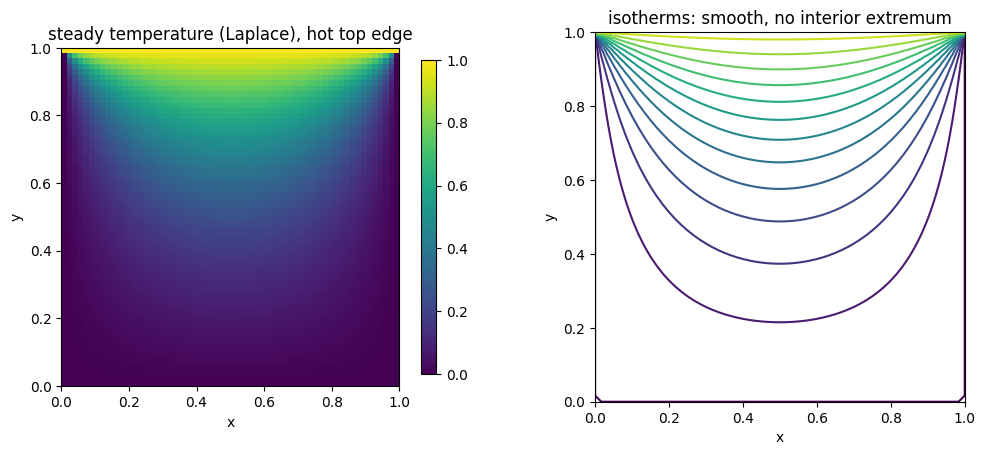

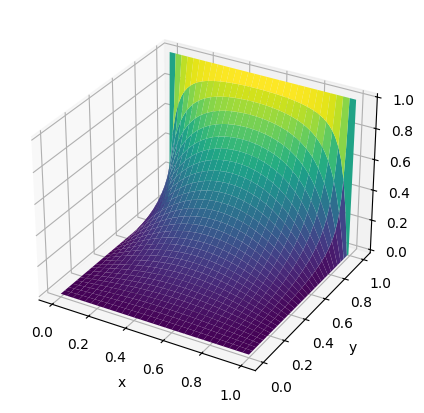

In [3]:
import numpy as np

# Steady temperature of a plate: top edge hot, others cold. Solve Laplace (rhs=0).
g = grids.Grid2D(0.0, 1.0, 0.0, 1.0, 61, 61)
boundary = datasets.hot_edge_boundary(g, value=1.0)
u = solvers.solve_poisson_2d(np.zeros((g.ny, g.nx)), g, boundary)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8))
plotting.heatmap_2d(u, grid=g, ax=a1, title="steady temperature (Laplace), hot top edge")
X, Y = g.meshgrid()
plotting.surface_2d(X, Y, u, ax=None)  # separate 3-D figure
cs = a2.contour(X, Y, u, levels=12, cmap="viridis")
a2.set_aspect("equal")
a2.set_title("isotherms: smooth, no interior extremum")
a2.set_xlabel("x")
a2.set_ylabel("y")
plt.show()

## 5. Poisson 方程式 — 湧き出しがある場合 (Applied)

$\nabla^2 u = f$。$f$ は熱源(または電荷密度)。中央に点状の源(湧き出し)を置くと、
そこを頂点に場が盛り上がります。境界は $0$(接地)に固定します。

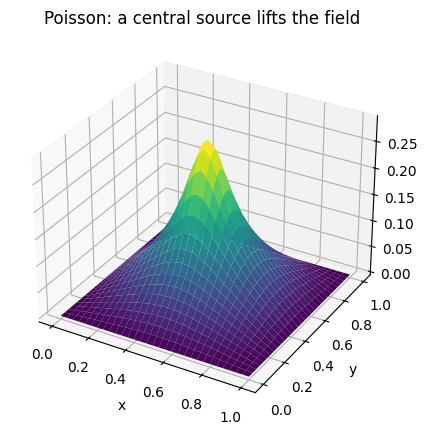

peak response at center: 0.2909


In [4]:
import numpy as np

# Poisson with a localized source in the middle (boundary grounded at 0).
g = grids.Grid2D(0.0, 1.0, 0.0, 1.0, 61, 61)
X, Y = g.meshgrid()
f = -50.0 * np.exp(-((X - 0.5) ** 2 + (Y - 0.5) ** 2) / 0.005)   # source term
u = solvers.solve_poisson_2d(f, g, boundary=np.zeros((g.ny, g.nx)))
ax = plotting.surface_2d(X, Y, u, title="Poisson: a central source lifts the field")
plt.show()
print("peak response at center:", round(float(u[g.ny // 2, g.nx // 2]), 4))

## 6. 調和関数の直感 — 平均値性

Laplace 方程式の解(**調和関数**)には美しい性質があります: **各点の値は、その周りの平均に等しい**
(平均値性)。離散版では「各内部点 = 上下左右の隣の平均」。最初の板の解で数値的に確かめます。

In [5]:
import numpy as np

# Mean-value property (discrete): interior value == average of its 4 neighbours.
g = grids.Grid2D(0.0, 1.0, 0.0, 1.0, 61, 61)
u = solvers.solve_poisson_2d(np.zeros((g.ny, g.nx)), g, datasets.hot_edge_boundary(g, 1.0))
nbr_avg = 0.25 * (u[2:, 1:-1] + u[:-2, 1:-1] + u[1:-1, 2:] + u[1:-1, :-2])
residual = np.max(np.abs(u[1:-1, 1:-1] - nbr_avg))
print("max |u_center - mean(4 neighbours)| =", residual, "(~0 confirms harmonicity)")

max |u_center - mean(4 neighbours)| = 4.440892098500626e-16 (~0 confirms harmonicity)


## Exercises

1. 4 辺すべて異なる温度に固定し、定常分布を解いて等温線を描け。
2. Poisson 方程式で源 $f$ の符号を反転すると、場が凹む(谷になる)ことを確かめよ。
3. 線形関数 $u = ax + by + c$ が調和($\nabla^2 u = 0$)であることを示し、数値解と一致させよ。

## Advanced Notes

- **最大値原理**: 調和関数は領域内部で最大・最小を取らない(必ず境界で取る)。だから板の内部温度は縁の温度の範囲に収まる。
- **平均値性 ⇔ 調和性**: 連続版では「任意の球面平均 = 中心値」が調和性と同値。
- **Green 関数**: Poisson 方程式の解は $u = \int G(x, x') f(x')\,dx'$。点源応答 $G$ を重ね合わせれば任意の源に対応できる。
- **Neumann と適合条件**: 全周 Neumann では、源の総量と境界流量が釣り合わないと定常解が存在しない(解は定数分だけ不定)。